# Overview
* Mean Imputation
* PCA + Logistic Regression
* PCA + KMeans + Logistic Regression
* Kmeans + Logistic Regression
    * Split Dataset First
    * Z-score Scaling
    * K-Means
        * Elbow
        * Silhouette
    * Add Cluster to Dataset
    * Logistic Regression
* Scatter Plot for k = 2, 3, 4, 5

# Load Dataset

In [1]:
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes.csv")
head(data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


In [2]:
sum(data$SkinThickness == 0)

[1] 227

In [3]:
Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"

In [4]:
train_data <- read.csv("train_data.csv")
test_data <- read.csv("test_data.csv")

In [5]:
dim(train_data)
dim(test_data)

[1] 614   9

[1] 154   9

In [6]:
head(train_data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,0,138,60,35,167,34.6,0.534,21,1
2,8,74,70,40,49,35.3,0.705,39,0
3,5,143,78,0,0,45.0,0.190,47,0
4,3,87,60,18,0,21.8,0.444,21,0
5,8,85,55,20,0,24.4,0.136,42,0
6,5,78,48,0,0,33.7,0.654,25,0


# Handle Missing Value
* *Glucose*
* *BloodPressure*
* *SkinThickness*
* *Insulin*
* *BMI*

### Mean

In [7]:
summary(train_data)

  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.:100.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :118.0   Median : 70.00   Median :23.00  
 Mean   : 3.793   Mean   :121.5   Mean   : 68.66   Mean   :20.79  
 3rd Qu.: 6.000   3rd Qu.:140.0   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :110.00   Max.   :99.00  
    Insulin            BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.00   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.00   1st Qu.:27.32   1st Qu.:0.2482           1st Qu.:24.00  
 Median : 41.00   Median :32.00   Median :0.3825           Median :29.00  
 Mean   : 81.63   Mean   :31.97   Mean   :0.4839           Mean   :33.18  
 3rd Qu.:130.00   3rd Qu.:36.58   3rd Qu.:0.6400           3rd Qu.:40.00  
 Max.   :846.00   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Ou

In [8]:
# ============================
# Check zeros before imputation
# ============================

cat("Zeros BEFORE imputation:\n")

colSums(
  test_data[, c(
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  )] == 0
)

# ============================
# Calculate means from TRAIN data
# ============================

mean_glucose_0 <- mean(train_data$Glucose[
  train_data$Outcome == 0 &
  train_data$Glucose != 0
])

mean_glucose_1 <- mean(train_data$Glucose[
  train_data$Outcome == 1 &
  train_data$Glucose != 0
])

mean_bp_0 <- mean(train_data$BloodPressure[
  train_data$Outcome == 0 &
  train_data$BloodPressure != 0
])

mean_bp_1 <- mean(train_data$BloodPressure[
  train_data$Outcome == 1 &
  train_data$BloodPressure != 0
])

mean_skin_0 <- mean(train_data$SkinThickness[
  train_data$Outcome == 0 &
  train_data$SkinThickness != 0
])

mean_skin_1 <- mean(train_data$SkinThickness[
  train_data$Outcome == 1 &
  train_data$SkinThickness != 0
])

mean_insulin_0 <- mean(train_data$Insulin[
  train_data$Outcome == 0 &
  train_data$Insulin != 0
])

mean_insulin_1 <- mean(train_data$Insulin[
  train_data$Outcome == 1 &
  train_data$Insulin != 0
])

mean_bmi_0 <- mean(train_data$BMI[
  train_data$Outcome == 0 &
  train_data$BMI != 0
])

mean_bmi_1 <- mean(train_data$BMI[
  train_data$Outcome == 1 &
  train_data$BMI != 0
])

print("Glucose 0 & 1")
mean_glucose_0
mean_glucose_1

print("BloodPressure 0 & 1")
mean_bp_0
mean_bp_1

print("SkinThickness 0 & 1")
mean_skin_0
mean_skin_1

print("Insulin 0 & 1")
mean_insulin_0
mean_insulin_1

print("BMI 0 & 1")
mean_bmi_0
mean_bmi_1

# ============================
# Impute TRAIN data
# ============================
# Glucose
train_data$Glucose[train_data$Outcome == 0 & train_data$Glucose == 0] <- mean_glucose_0
train_data$Glucose[train_data$Outcome == 1 & train_data$Glucose == 0] <- mean_glucose_1

# BloodPressure
train_data$BloodPressure[train_data$Outcome == 0 & train_data$BloodPressure == 0] <- mean_bp_0
train_data$BloodPressure[train_data$Outcome == 1 & train_data$BloodPressure == 0] <- mean_bp_1

# SkinThickness
train_data$SkinThickness[train_data$Outcome == 0 & train_data$SkinThickness == 0] <- mean_skin_0
train_data$SkinThickness[train_data$Outcome == 1 & train_data$SkinThickness == 0] <- mean_skin_1

# Insulin
train_data$Insulin[train_data$Outcome == 0 & train_data$Insulin == 0] <- mean_insulin_0
train_data$Insulin[train_data$Outcome == 1 & train_data$Insulin == 0] <- mean_insulin_1

# BMI
train_data$BMI[train_data$Outcome == 0 & train_data$BMI == 0] <- mean_bmi_0
train_data$BMI[train_data$Outcome == 1 & train_data$BMI == 0] <- mean_bmi_1


# ============================
# Impute TEST data
# ============================

# Glucose
test_data$Glucose[test_data$Outcome == 0 &
                  test_data$Glucose == 0] <- mean_glucose_0

test_data$Glucose[test_data$Outcome == 1 &
                  test_data$Glucose == 0] <- mean_glucose_1

# BloodPressure
test_data$BloodPressure[test_data$Outcome == 0 &
                        test_data$BloodPressure == 0] <- mean_bp_0

test_data$BloodPressure[test_data$Outcome == 1 &
                        test_data$BloodPressure == 0] <- mean_bp_1

# SkinThickness
test_data$SkinThickness[test_data$Outcome == 0 &
                        test_data$SkinThickness == 0] <- mean_skin_0

test_data$SkinThickness[test_data$Outcome == 1 &
                        test_data$SkinThickness == 0] <- mean_skin_1

# Insulin
test_data$Insulin[test_data$Outcome == 0 &
                  test_data$Insulin == 0] <- mean_insulin_0

test_data$Insulin[test_data$Outcome == 1 &
                  test_data$Insulin == 0] <- mean_insulin_1

# BMI
test_data$BMI[test_data$Outcome == 0 &
              test_data$BMI == 0] <- mean_bmi_0

test_data$BMI[test_data$Outcome == 1 &
              test_data$BMI == 0] <- mean_bmi_1

# ============================
# Check zeros after imputation
# ============================

cat("\nZeros AFTER imputation:\n")

colSums(
  test_data[, c(
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  )] == 0
)

# ============================
# Predict using trained model
# ============================
model <- glm(Outcome ~., data = train_data, family = binomial)
summary(model)


# ============================
# Predict using trained model
# ============================

prob <- predict(
  model,
  newdata = test_data,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

# ============================
# Confusion Matrix
# ============================

conf_matrix <- table(
  Predicted = pred,
  Actual = test_data$Outcome
)

print(conf_matrix)

# ============================
# Metrics
# ============================

TP <- conf_matrix["1","1"]
TN <- conf_matrix["0","0"]
FP <- conf_matrix["1","0"]
FN <- conf_matrix["0","1"]

accuracy <- (TP + TN) / sum(conf_matrix)

precision <- TP / (TP + FP)

recall <- TP / (TP + FN)

f1 <- 2 * precision * recall /
      (precision + recall)

cat("\nAccuracy :", round(accuracy, 4))
cat("\nPrecision:", round(precision, 4))
cat("\nRecall   :", round(recall, 4))
cat("\nF1 Score :", round(f1, 4))

Zeros BEFORE imputation:


Glucose BloodPressure SkinThickness       Insulin           BMI 
            1             7            51            82             3

[1] "Glucose 0 & 1"


[1] 110.9848

[1] 143.2103

...

[1] 35.3785


Zeros AFTER imputation:


Glucose BloodPressure SkinThickness       Insulin           BMI 
            0             0             0             0             0


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_data)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -9.248094   0.930778  -9.936  < 2e-16 ***
Pregnancies               0.111406   0.036084   3.087  0.00202 ** 
Glucose                   0.030661   0.004444   6.899 5.23e-12 ***
BloodPressure            -0.007664   0.010024  -0.765  0.44453    
SkinThickness             0.038266   0.015405   2.484  0.01299 *  
Insulin                   0.007093   0.001741   4.075 4.60e-05 ***
BMI                       0.057155   0.020314   2.814  0.00490 ** 
DiabetesPedigreeFunction  0.639411   0.328280   1.948  0.05144 .  
Age                       0.011158   0.010776   1.035  0.30046    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 542.47  on 605  degrees of freedom
AIC: 560.

         Actual
Predicted  0  1
        0 90 21
        1 12 31

Accuracy : 0.7857
Precision: 0.7209
Recall   : 0.5962
F1 Score : 0.6526

In [9]:
coef_summary <- summary(model)$coefficients

pvalue_table <- data.frame(
  Predictor = c("Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"),
  P_Value = coef_summary[c("Glucose",
                           "BloodPressure",
                           "SkinThickness",
                           "Insulin",
                           "BMI"), "Pr(>|z|)"]
)

pvalue_table

,Predictor,P_Value
,<chr>,<dbl>
Glucose,Glucose,5.233815e-12
BloodPressure,BloodPressure,4.445294e-01
SkinThickness,SkinThickness,1.299202e-02
Insulin,Insulin,4.598949e-05
BMI,BMI,4.898274e-03


In [10]:
BIC(model)

[1] 600.246

# PCA + Logistic Regression

### Split X and Y

In [11]:
train_x <- subset(train_data, select = -Outcome)
train_y <- train_data$Outcome

test_x <- subset(test_data, select = -Outcome)
test_y <- test_data$Outcome

### Z-Score Scaling

In [12]:
# Calculate mean and sd from TRAINING DATA ONLY
train_mean <- apply(train_x, 2, mean)
train_sd <- apply(train_x, 2, sd)

In [13]:
# Scale training data
train_scaled <- scale(
  train_x,
  center = train_mean,
  scale = train_sd
)

In [14]:
# Scale testing data using TRAINING statistics
test_scaled <- scale(
  test_x,
  center = train_mean,
  scale = train_sd
)

### PCA

In [15]:
pca_model <- prcomp(
  train_scaled,
  center = FALSE,
  scale. = FALSE
)

# Variance explained
summary(pca_model)

Importance of components:
                          PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     1.5506 1.2189 1.0539 0.9532 0.86925 0.70669 0.67831
Proportion of Variance 0.3006 0.1857 0.1388 0.1136 0.09445 0.06243 0.05751
Cumulative Proportion  0.3006 0.4863 0.6251 0.7387 0.83314 0.89557 0.95308
                           PC8
Standard deviation     0.61268
Proportion of Variance 0.04692
Cumulative Proportion  1.00000

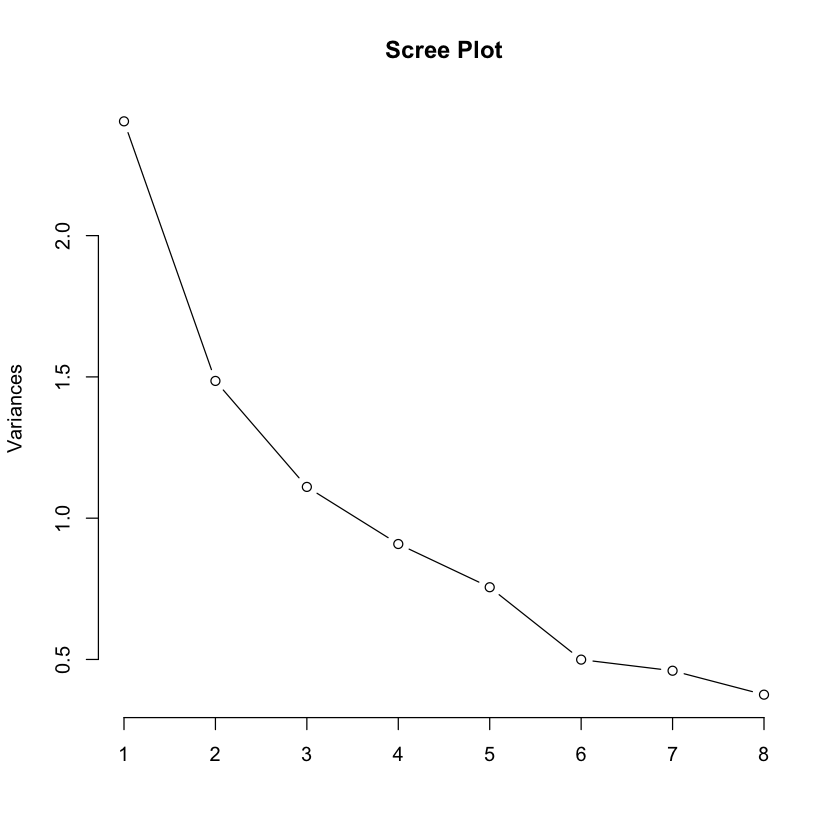

In [16]:
# Scree Plot
par (bg = "White")
plot(
  pca_model,
  type = "l",
  main = "Scree Plot"
)

### Transform Data

In [17]:
train_pca <- predict(
  pca_model,
  newdata = train_scaled
)

test_pca <- predict(
  pca_model,
  newdata = test_scaled
)

### Select First 5 PCs

In [18]:
num_pc <- 5

train_pca_df <- data.frame(
  train_pca[, 1:num_pc],
  Outcome = train_y
)

test_pca_df <- data.frame(
  test_pca[, 1:num_pc]
)


### Logistic Regression

In [19]:
head(train_pca_df)

,PC1,PC2,PC3,PC4,PC5,Outcome
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,-9.309023,0.3236229,2.428026,0.01500526,2.668193,1
2,-8.821492,0.4580744,2.884086,1.40453783,2.699233,0
3,-9.488882,1.3301312,1.177279,-2.38515283,3.189270,0
4,-9.577060,0.8437675,2.268840,-0.60458106,2.776101,0
5,-9.798597,1.7660156,1.215947,-2.74338591,3.414851,0
6,-9.123600,0.3886676,2.861147,0.96673823,2.700708,0


In [20]:
model <- glm(
  Outcome ~ .,
  data = train_pca_df,
  family = binomial
)

summary(model)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_pca_df)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 199.1649    19.0022  10.481  < 2e-16 ***
PC1          28.8175     2.7282  10.563  < 2e-16 ***
PC2          -6.1937     0.8397  -7.376 1.63e-13 ***
PC3          27.9813     3.2935   8.496  < 2e-16 ***
PC4         -19.6174     2.1544  -9.106  < 2e-16 ***
PC5           1.1421     1.1543   0.989    0.322    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 549.39  on 608  degrees of freedom
AIC: 561.39

Number of Fisher Scoring iterations: 5


In [21]:
BIC(model)

[1] 587.9056

### Prediction

In [22]:
prob <- predict(
  model,
  newdata = test_pca_df,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

In [23]:
cm <- table(
  Actual = test_y,
  Predicted = pred
)

cm

      Predicted
Actual  0  1
     0 89 13
     1 20 32

In [24]:
accuracy <- sum(diag(cm)) / sum(cm)

precision <- cm["1","1"] /
             (cm["0","1"] + cm["1","1"])

recall <- cm["1","1"] /
          (cm["1","0"] + cm["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy,4), "\n")
cat("Precision =", round(precision,4), "\n")
cat("Recall =", round(recall,4), "\n")
cat("F1 Score =", round(f1,4), "\n")

Accuracy = 0.7857 
Precision = 0.7111 
Recall = 0.6154 
F1 Score = 0.6598 


# PCA + KMeans + Logistic Regression

### KMeans

In [25]:
set.seed(123)

k <- 3 
kmeans_model <- kmeans(train_pca[, 1:num_pc], centers = k, nstart = 25)

In [26]:
kmeans_model

K-means clustering with 3 clusters of sizes 374, 41, 199

Cluster means:
        PC1        PC2      PC3       PC4      PC5
1 -9.569211  1.1448462 1.564246 -1.797939 3.047606
2 -8.006142 -1.1574117 5.313647  6.396044 1.516998
3 -8.998467  0.3221719 2.916926  1.170718 2.504095

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  3   3   1   1   1   3   1   2   2   1   1   1   1   1   1   1   1   1   3   1 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  1   1   2   1   1   1   1   3   1   1   3   1   1   2   3   3   3   3   1   1 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  1   1   3   1   1   2   3   1   1   1   1   1   1   1   1   3   3   1   3   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  1   1   1   1   1   2   1   2   1   1   1   1   1   1   3   3   3   1   3   3 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94

### Add Cluster Label

In [27]:
train_cluster <- kmeans_model$cluster

test_cluster <- 
predict_kmeans <- function(test_data, centers) {
  apply(test_data, 1, function(x) {
    which.min(colSums((t(centers) - x)^2))
  })
}

test_cluster <- predict_kmeans(test_pca[, 1:5], kmeans_model$centers)

In [28]:
train_df <- data.frame(
  train_pca[, 1:5],
  Cluster = as.factor(train_cluster),
  Outcome = train_data$Outcome
)

test_df <- data.frame(
  test_pca[, 1:5],
  Cluster = as.factor(test_cluster)
)

In [29]:
head(train_df)
head(test_df)

,PC1,PC2,PC3,PC4,PC5,Cluster,Outcome
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>
1,-9.309023,0.3236229,2.428026,0.01500526,2.668193,3,1
2,-8.821492,0.4580744,2.884086,1.40453783,2.699233,3,0
3,-9.488882,1.3301312,1.177279,-2.38515283,3.189270,1,0
4,-9.577060,0.8437675,2.268840,-0.60458106,2.776101,1,0
5,-9.798597,1.7660156,1.215947,-2.74338591,3.414851,1,0
6,-9.123600,0.3886676,2.861147,0.96673823,2.700708,3,0


,PC1,PC2,PC3,PC4,PC5,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,-8.937686,0.5815202,2.703158,0.7913152,2.689158,3
2,-8.976454,0.6142784,2.969617,1.1020832,2.695339,3
3,-9.599740,1.3031473,1.180131,-2.6766230,3.251200,1
4,-9.053219,0.2086348,2.274659,0.1683258,2.613946,3
5,-9.230948,1.1959496,1.863749,-0.9028509,2.980706,1
6,-9.380976,1.3092152,1.422985,-1.8829933,3.197533,1


### Train LR

In [30]:
model <- glm(
  Outcome ~ .,
  data = train_df,
  family = binomial
)
summary(model)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_df)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) 199.56657   19.02806  10.488  < 2e-16 ***
PC1          28.88364    2.73426  10.564  < 2e-16 ***
PC2          -6.20046    0.83969  -7.384 1.53e-13 ***
PC3          28.06839    3.30293   8.498  < 2e-16 ***
PC4         -19.66706    2.16056  -9.103  < 2e-16 ***
PC5           1.13994    1.15403   0.988    0.323    
Cluster2     -0.14150    0.95663  -0.148    0.882    
Cluster3      0.06116    0.40905   0.150    0.881    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 549.18  on 606  degrees of freedom
AIC: 565.18

Number of Fisher Scoring iterations: 5


In [31]:
prob <- predict(model, newdata = test_df, type = "response")
pred <- ifelse(prob > 0.5, 1, 0)

actual <- test_data$Outcome
accuracy <- mean(pred == actual)
accuracy

[1] 0.7857143

### Evaluation

In [32]:
cm <- table(
  Actual = test_y,
  Predicted = pred
)

accuracy <- sum(diag(cm)) / sum(cm)

precision <- cm["1","1"] /
             (cm["0","1"] + cm["1","1"])

recall <- cm["1","1"] /
          (cm["1","0"] + cm["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy,4), "\n")
cat("Precision =", round(precision,4), "\n")
cat("Recall =", round(recall,4), "\n")
cat("F1 Score =", round(f1,4), "\n")

Accuracy = 0.7857 
Precision = 0.7111 
Recall = 0.6154 
F1 Score = 0.6598 


# KMeans + Logistic Regression

In [33]:
# ====================================
# K-Means + Logistic Regression
# ====================================

# ============================
# Split X and Y
# ============================

train_x <- subset(train_data, select = -Outcome)
train_y <- train_data$Outcome

test_x <- subset(test_data, select = -Outcome)
test_y <- test_data$Outcome

# ============================
# Z-score Scaling
# ============================

train_mean <- apply(train_x, 2, mean)
train_sd <- apply(train_x, 2, sd)

train_scaled <- scale(
  train_x,
  center = train_mean,
  scale = train_sd
)

test_scaled <- scale(
  test_x,
  center = train_mean,
  scale = train_sd
)

# ============================
# K-Means
# ============================

set.seed(123)

# =============================
# k value
# =============================
k <- 2

kmeans_model <- kmeans(
  train_scaled,
  centers = k,
  nstart = 25
)

# Training cluster labels
train_cluster <- kmeans_model$cluster

# ============================
# Predict cluster for test data
# ============================

predict_kmeans <- function(test_data, centers) {

  apply(test_data, 1, function(x) {

    distances <- colSums(
      (t(centers) - x)^2
    )

    which.min(distances)

  })

}

test_cluster <- predict_kmeans(
  test_scaled,
  kmeans_model$centers
)

# ============================
# Create LR datasets
# ============================

train_df <- data.frame(
  train_scaled,
  Cluster = factor(train_cluster),
  Outcome = train_y
)

test_df <- data.frame(
  test_scaled,
  Cluster = factor(test_cluster)
)

# ============================
# Logistic Regression
# ============================

model <- glm(
  Outcome ~ .,
  data = train_df,
  family = binomial
)

summary(model)

# ============================
# Prediction
# ============================

prob <- predict(
  model,
  newdata = test_df,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

# ============================
# Confusion Matrix
# ============================

cm <- table(
  Actual = test_y,
  Predicted = pred
)

print(cm)

# ============================
# Evaluation Metrics
# ============================

accuracy <- sum(diag(cm)) / sum(cm)

precision <- cm["1","1"] /
             (cm["0","1"] + cm["1","1"])

recall <- cm["1","1"] /
          (cm["1","0"] + cm["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy, 4), "\n")
cat("Precision =", round(precision, 4), "\n")
cat("Recall =", round(recall, 4), "\n")
cat("F1 Score =", round(f1, 4), "\n")


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_df)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.44126    0.22992  -1.919  0.05496 .  
Pregnancies               0.28422    0.12737   2.232  0.02564 *  
Glucose                   0.83101    0.14148   5.874 4.27e-09 ***
BloodPressure            -0.20401    0.13109  -1.556  0.11966    
SkinThickness             0.25159    0.14367   1.751  0.07992 .  
Insulin                   0.53346    0.16221   3.289  0.00101 ** 
BMI                       0.34264    0.14100   2.430  0.01510 *  
DiabetesPedigreeFunction  0.21224    0.11290   1.880  0.06012 .  
Age                       0.02289    0.13705   0.167  0.86736    
Cluster2                 -0.77099    0.36741  -2.098  0.03587 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual 

      Predicted
Actual  0  1
     0 87 15
     1 19 33
Accuracy = 0.7792 
Precision = 0.6875 
Recall = 0.6346 
F1 Score = 0.66 


In [34]:
BIC(model)

[1] 602.2246

### Testing

In [35]:
head(train_df)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,Outcome
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>
1,-1.1326702,0.5193944,-1.0020053,0.6498554,0.1167341,0.3238672,0.1460368,-1.0304267,2,1
2,1.2561989,-1.6007830,-0.1642249,1.2093515,-1.1870329,0.4262431,0.6441359,0.4928847,2,0
3,0.3603730,0.6850332,0.5059994,-0.2150324,-0.2989016,1.8448815,-0.8559872,1.1699120,1,0
4,-0.2368443,-1.1701220,-1.0020053,-1.2524315,-0.2989016,-1.5481505,-0.1161207,-1.0304267,2,0
5,1.2561989,-1.2363776,-1.4208954,-1.0286330,-0.2989016,-1.1678969,-1.0132816,0.7467699,2,0
6,0.3603730,-1.4682720,-2.0073417,-0.2150324,-0.2989016,0.1922409,0.4955800,-0.6919131,2,0


In [36]:
model_cluster <- glm(Outcome ~ . -Cluster, data = train_df, family = binomial)
summary(model_cluster)


Call:
glm(formula = Outcome ~ . - Cluster, family = binomial, data = train_df)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.86926    0.11250  -7.727 1.10e-14 ***
Pregnancies               0.37309    0.12084   3.087  0.00202 ** 
Glucose                   0.92554    0.13415   6.899 5.23e-12 ***
BloodPressure            -0.09148    0.11965  -0.765  0.44453    
SkinThickness             0.34197    0.13767   2.484  0.01299 *  
Insulin                   0.64197    0.15753   4.075 4.60e-05 ***
BMI                       0.39080    0.13890   2.814  0.00490 ** 
DiabetesPedigreeFunction  0.21951    0.11270   1.948  0.05144 .  
Age                       0.13185    0.12734   1.035  0.30046    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 542.47  on 605  degrees of freedom
AIC: 560.47

In [37]:
prob_cluster <- predict(
  model_cluster,
  newdata = test_df,
  type = "response"
)

pred_cluster <- ifelse(prob_cluster > 0.5, 1, 0)

# ============================
# Confusion Matrix
# ============================

cm_c <- table(
  Actual = test_y,
  Predicted = pred_cluster
)

print(cm_c)

# ============================
# Evaluation Metrics
# ============================

accuracy_c <- sum(diag(cm_c)) / sum(cm_c)

precision_c <- cm_c["1","1"] /
             (cm_c["0","1"] + cm_c["1","1"])

recall <- cm_c["1","1"] /
          (cm_c["1","0"] + cm_c["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy, 4), "\n")
cat("Precision =", round(precision, 4), "\n")
cat("Recall =", round(recall, 4), "\n")
cat("F1 Score =", round(f1, 4), "\n")

      Predicted
Actual  0  1
     0 90 12
     1 21 31


Accuracy = 0.7792 
Precision = 0.6875 
Recall = 0.5962 
F1 Score = 0.6386 


### Testing End

### Elbow
* WSS(Within-Cluster Sum of Squares)

In [38]:
set.seed(123)

wss <- numeric(19)

for (i in 1:19) {

  km <- kmeans(
    train_scaled,
    centers = i,
    nstart = 25
  )

  wss[i] <- km$tot.withinss
}

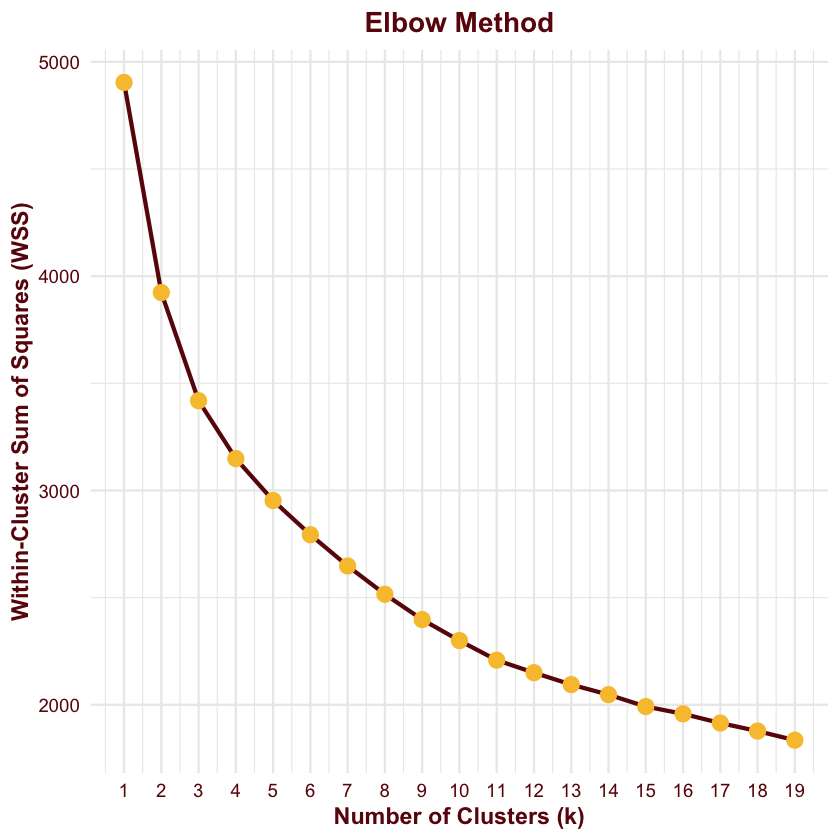

In [39]:
library(ggplot2)

Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)

elbow_df <- data.frame(
  k = 1:19,
  WSS = wss
)

ggplot(elbow_df,
       aes(x = k, y = WSS)) +

  geom_line(
    linewidth = 1.2,
    color = Garnet
  ) +

  geom_point(
    size = 4,
    color = Gold
  ) +

  # geom_vline(
  #   xintercept = 4,
  #   linetype = "dashed",
  #   linewidth = 1,
  #   color = Gold
  # ) +

  # annotate(
  #   "text",
  #   x = 4.8,
  #   y = max(wss) * 0.97,
  #   label = "Selected k = 4",
  #   color = Garnet,
  #   fontface = "bold",
  #   size = 5
  # ) +

  scale_x_continuous(breaks = 1:19) +

  labs(
    title = "Elbow Method",
    x = "Number of Clusters (k)",
    y = "Within-Cluster Sum of Squares (WSS)"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5,
      color = Garnet
    ),
    axis.title = element_text(
      face = "bold",
      color = Garnet
    ),
    axis.text = element_text(
      color = Garnet
    ) 
  )

In [40]:
improvement_table <- data.frame(
  From_k = 1:18,
  To_k = 2:19,
  WSS_Drop = round(
    wss[1:18] - wss[2:19],
    2
  ),
  Percent_Drop = round(
    (wss[1:18] - wss[2:19]) /
    wss[1:18] * 100,
    2
  )
)

improvement_table

From_k,To_k,WSS_Drop,Percent_Drop
<int>,<int>,<dbl>,<dbl>
1,2,980.36,19.99
2,3,504.80,12.87
3,4,270.18,7.90
4,5,195.42,6.21
5,6,159.57,5.40
6,7,145.89,5.22
7,8,131.89,4.98
8,9,118.17,4.70
9,10,98.10,4.09


***k = 4***             
The Elbow Method was used to determine the optimal number of clusters. The WSS decreased rapidly as the number of clusters increased from 1 to 4, but the rate of improvement slowed noticeably beyond k=4. Therefore, k=4 was selected as the optimal number of clusters.              
The reduction in WSS becomes noticeable smaller after *k = 4*, indicating diminishing returns from adding more clusters. 

### Silhouette Plot

In [41]:
library(factoextra)
library(cluster)

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [42]:
# set.seed(123)

# fviz_nbclust(
#   train_scaled,
#   kmeans,
#   method = "silhouette",
#   k.max = 19
# ) +
#   labs(
#     title = "Silhouette Method for Optimal k",
#     x = "Number of Clusters (k)",
#     y = "Average Silhouette Width"
#   ) +
#   theme_minimal(base_size = 14)

In [43]:
library(cluster)

sil_width <- numeric(19)

for(k in 2:20){

  km <- kmeans(
    train_scaled,
    centers = k,
    nstart = 25
  )

  ss <- silhouette(
    km$cluster,
    dist(train_scaled)
  )

  sil_width[k - 1] <- mean(ss[, 3])
}

sil_df <- data.frame(
  k = 2:20,
  Avg_Silhouette = round(sil_width, 4)
)

sil_df

k,Avg_Silhouette
<int>,<dbl>
2,0.2039
3,0.2008
4,0.1825
5,0.1397
6,0.1332
7,0.1358
8,0.1407
9,0.1519
10,0.1519


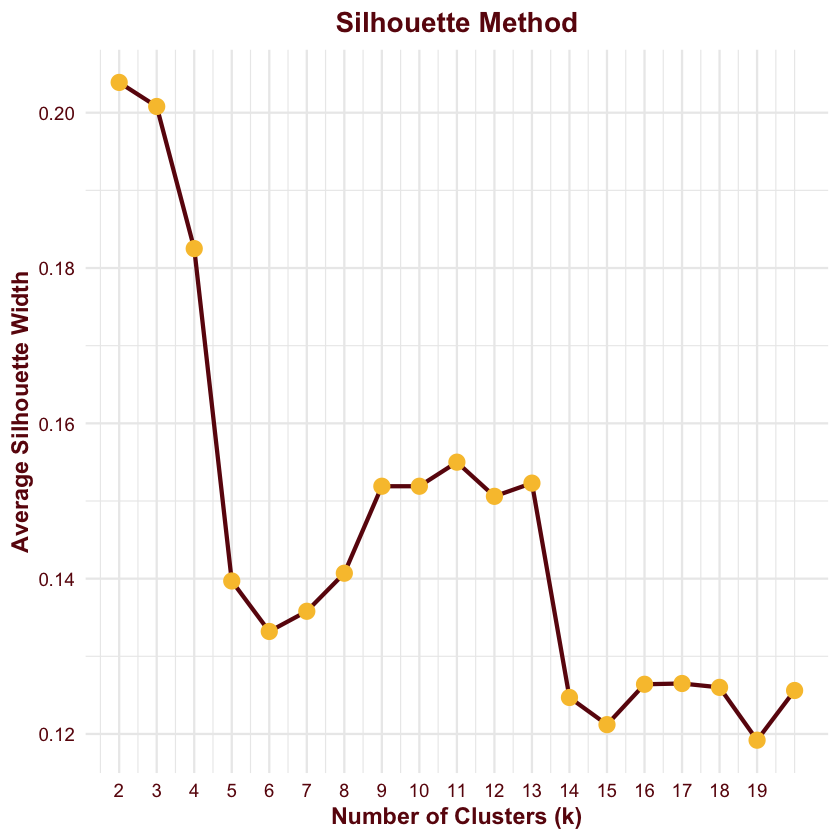

In [44]:
library(ggplot2)

Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)

best_k <- sil_df$k[which.max(sil_df$Avg_Silhouette)]

ggplot(
  sil_df,
  aes(x = k, y = Avg_Silhouette)
) +

  geom_line(
    linewidth = 1.2,
    color = Garnet
  ) +

  geom_point(
    size = 4,
    color = Gold
  ) +

  # geom_vline(
  #   xintercept = best_k,
  #   linetype = "dashed",
  #   linewidth = 1,
  #   color = Gold
  # ) +

  # annotate(
  #   "text",
  #   x = best_k + 0.5,
  #   y = max(sil_df$Avg_Silhouette),
  #   label = paste("Best k =", best_k),
  #   color = Garnet,
  #   fontface = "bold",
  #   size = 5
  # ) +

  scale_x_continuous(
    breaks = 2:19
  ) +

  labs(
    title = "Silhouette Method",
    x = "Number of Clusters (k)",
    y = "Average Silhouette Width"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5,
      color = Garnet
    ),
    axis.title = element_text(
      face = "bold",
      color = Garnet
    ),
    axis.text = element_text(
      color = Garnet
    )
  )

# Scotter Plot

In [45]:
library(factoextra)
library(gridExtra)

In [46]:
kmeans_3 <- kmeans(train_pca[,1:5],
                   centers = 3,
                   nstart = 25)

In [47]:
cluster_colors_5 <- c(
  Garnet,          
  Gold,           
  "#B88A8B",    
  "#D4B45E",     
  "#8A8A8A"      
)

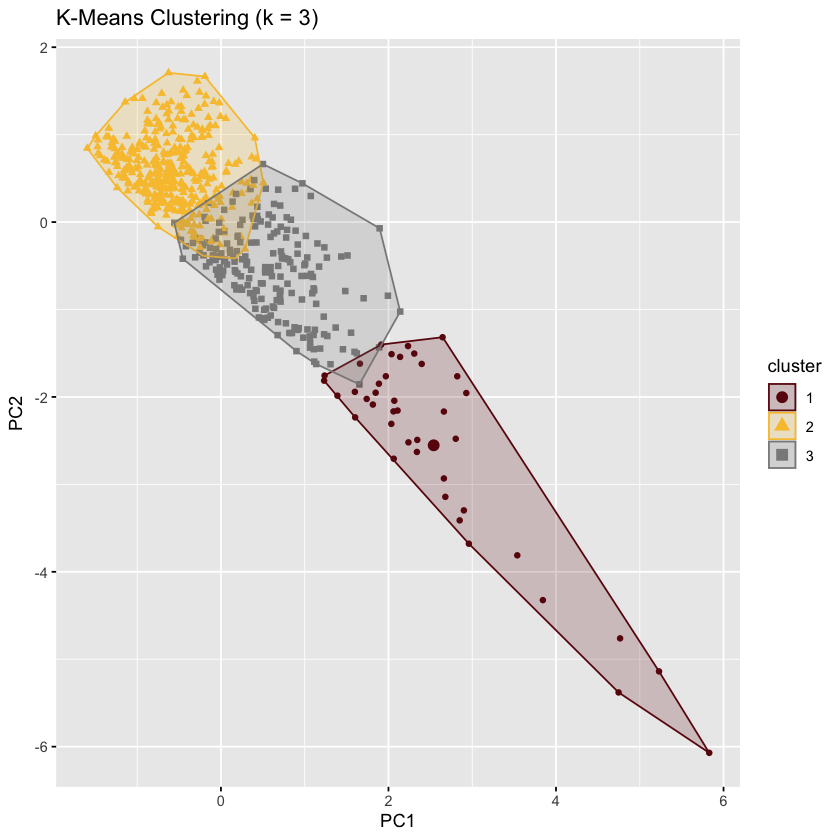

In [48]:
fviz_cluster(
  kmeans_3,
  data = train_pca[,1:2],
  geom = "point",
  ellipse.type = "convex",
  main = "K-Means Clustering (k = 3)",
  palette = c(
    Garnet,      
    Gold,        
    "#8A8A8A"   
  )
)

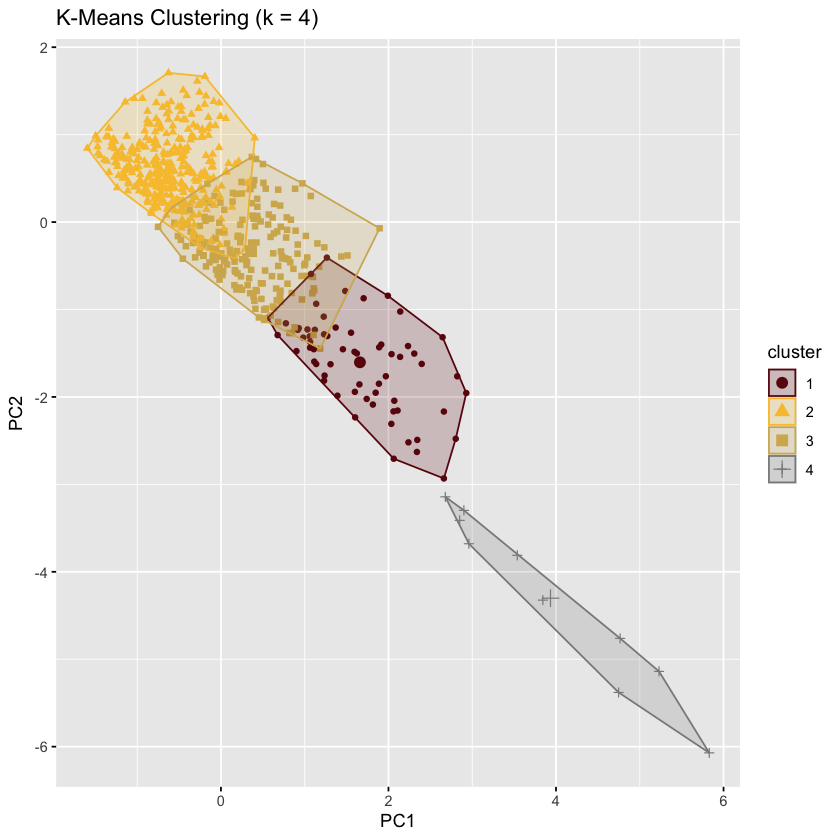

In [49]:
kmeans_4 <- kmeans(train_pca[,1:5],
                   centers = 4,
                   nstart = 25)

fviz_cluster(
  kmeans_4,
  data = train_pca[,1:2],
  geom = "point",
  ellipse.type = "convex",
  main = "K-Means Clustering (k = 4)",
  palette = c(
    Garnet,      
    Gold,        
    "#D4B45E",   
    "#8A8A8A"  
  )
)

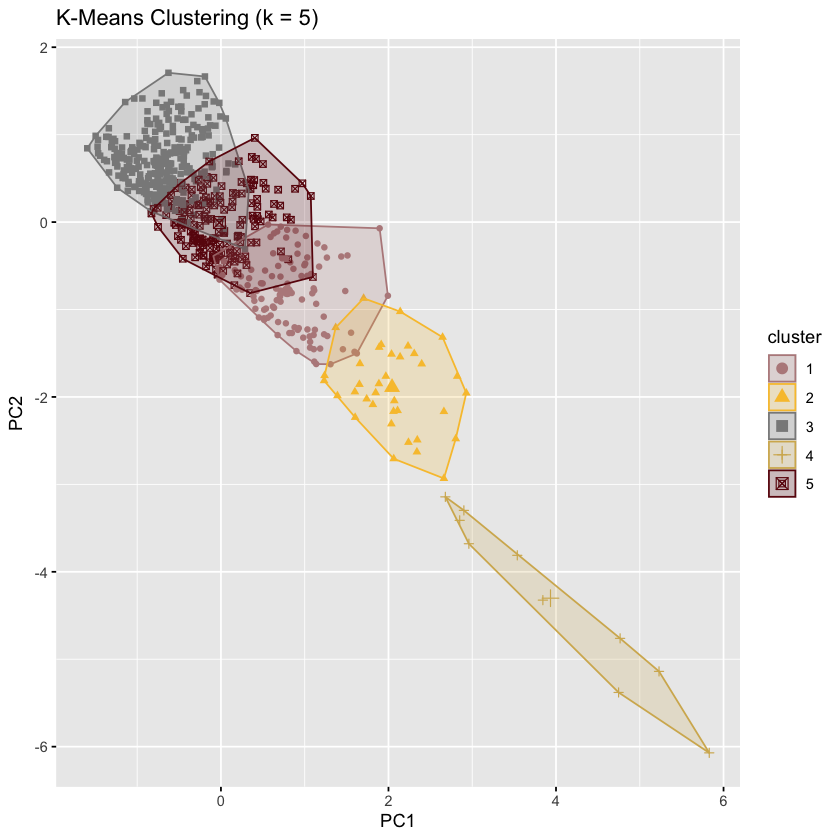

In [50]:
kmeans_5 <- kmeans(train_pca[,1:5],
                   centers = 5,
                   nstart = 25)

fviz_cluster(
  kmeans_5,
  data = train_pca[,1:2],
  geom = "point",
  ellipse.type = "convex",
  main = "K-Means Clustering (k = 5)",
  palette = c(
    "#B88A8B",   
    Gold,        
    "#8A8A8A",  
    "#D4B45E", 
    Garnet  
  )      
)

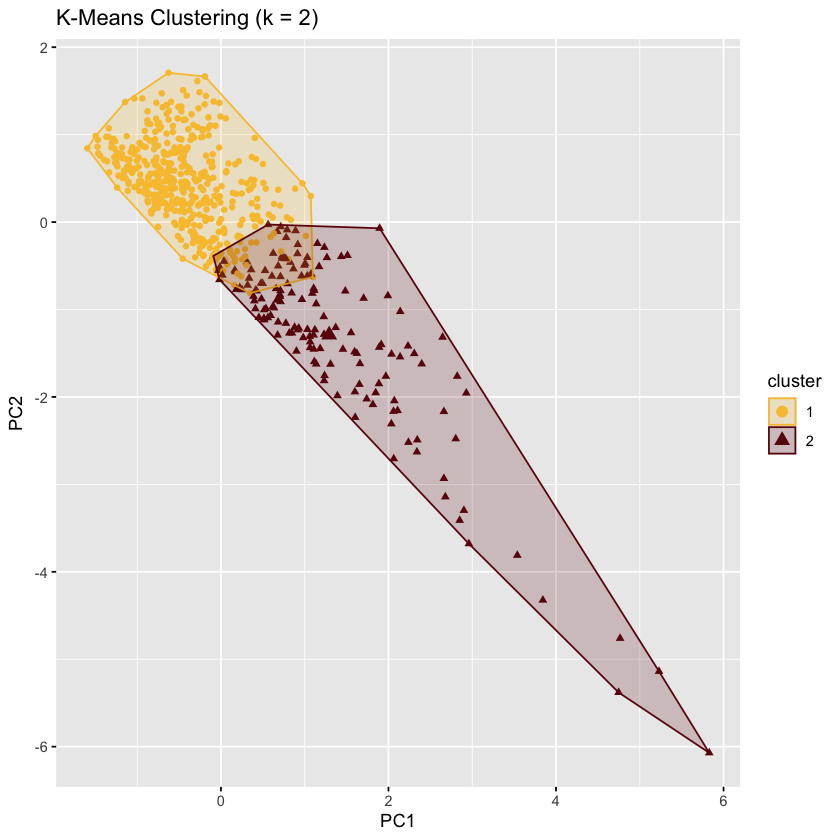

In [51]:
kmeans_2 <- kmeans(train_pca[,1:5],
                   centers = 2,
                   nstart = 25)

fviz_cluster(
  kmeans_2,
  data = train_pca[,1:2],
  geom = "point",
  ellipse.type = "convex",
  main = "K-Means Clustering (k = 2)",
  palette = c(  
    Gold,         
    Garnet  
  )      
)